# Experiment 1: Single Layer Perceptron for Binary Classification
**CS3807 - Deep Learning Laboratory | AY 2026-27**

Dataset: Banknote Authentication (UCI ML Repository, id=267)

**Objective:** Implement a Single Layer Perceptron from scratch for binary classification, understand the perceptron learning rule, visualize training behaviour, and evaluate the classifier.

## Setup: Install & Import Libraries

In [1]:
!pip install ucimlrepo -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix

plt.style.use("ggplot")
sns.set_theme(style="ticks", font_scale=1.1)

## Task 1: Dataset Exploration

In [3]:
# Load the dataset
banknote = fetch_ucirepo(id=267)

X = banknote.data.features
y = banknote.data.targets

dataset = pd.concat([X, y], axis=1)
df = dataset
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
print("="*50)
print("BANKNOTE DATASET OVERVIEW")
print("="*50)

print("\nFirst Five Records")
print(df.head())

print("\nDataset Dimensions")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

BANKNOTE DATASET OVERVIEW

First Five Records
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Dimensions
(1372, 5)

Missing Values
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Statistical Summary
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475 

**Interpretation:** The dataset has 1372 samples with 4 numerical features (variance, skewness, curtosis, entropy) and no missing values, so no imputation is needed. The `describe()` output shows the features are on very different scales (variance/skewness range roughly -7 to 12, while entropy is mostly negative), which confirms normalization is required before training the perceptron.

## Task 2: Exploratory Data Analysis

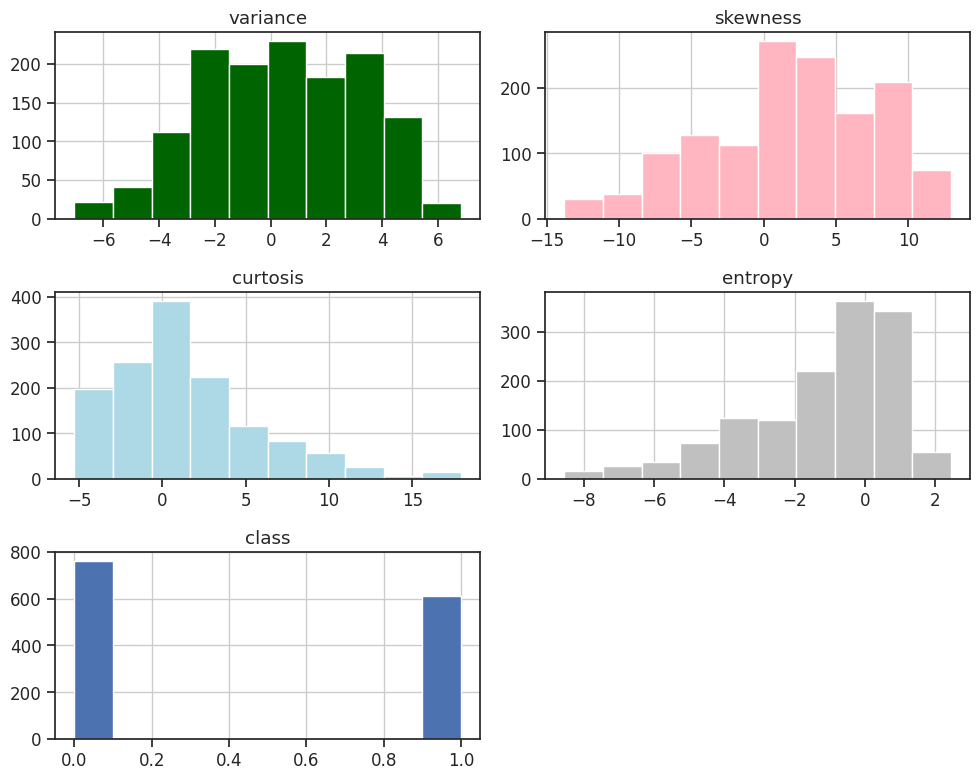

In [5]:
#Histograms
colors = ['Darkgreen', 'lightpink', 'Lightblue', 'silver']

axes = df.hist(figsize=(10,8), edgecolor='white')

for ax, color in zip(axes.flatten(), colors):
    for patch in ax.patches:
        patch.set_facecolor(color)

plt.tight_layout()
plt.show()

**Interpretation:** Variance and skewness look roughly bell-shaped with a slight skew, while curtosis and entropy show heavier tails and a few outlier-like values. Entropy is strongly left-skewed, with most values clustered near the upper end of its range.

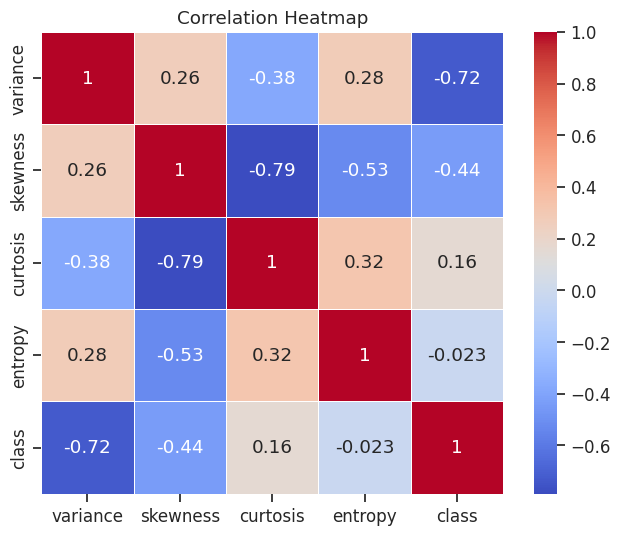

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.show()

**Interpretation:** `variance` has the strongest (negative) correlation with `class`, making it the most discriminative single feature. `skewness` and `curtosis` are moderately correlated with each other, while `entropy` is only weakly correlated with the other features, suggesting it adds independent information.

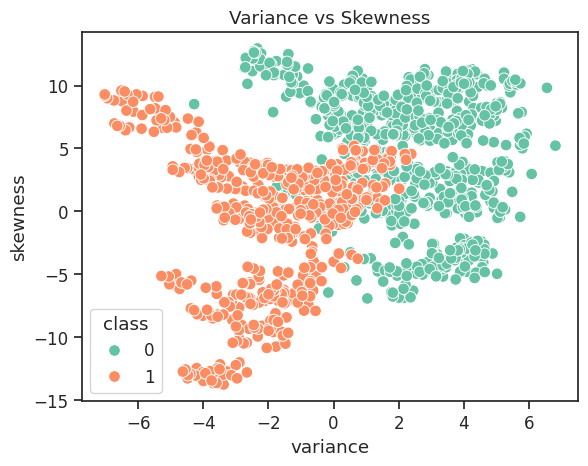

In [7]:
sns.scatterplot(
    data=df,
    x="variance",
    y="skewness",
    hue="class",
    palette="Set2",
    s=70
)

plt.title("Variance vs Skewness")
plt.show()

**Interpretation:** The two classes form largely separate clusters along the variance axis, with only a modest region of overlap. This indicates the classes are close to linearly separable in this 2-feature projection, which is exactly the condition a single layer perceptron needs to converge well.

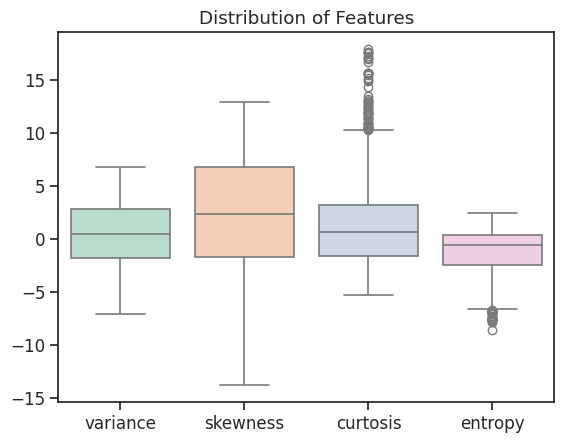

In [8]:
sns.boxplot(
    data=df.iloc[:,:4],
    palette="Pastel2",
    linewidth=1.2
)

plt.title("Distribution of Features")
plt.show()

**Interpretation:** `curtosis` and `entropy` show a number of outlier points beyond the whiskers, while `variance` and `skewness` are comparatively well-behaved. This further supports normalizing all features so that no single feature's scale dominates the weighted sum during training.

## Task 3: Data Preprocessing

In [9]:
#Data preprocessing
X = df.iloc[:,:4].values
y = df.iloc[:,4].values

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Train set:", X_train.shape, "Test set:", X_test.shape)

Train set: (1097, 4) Test set: (275, 4)


## Task 4 & 5: Perceptron Implementation and Training

In [10]:
# Perceptron Class Implementation
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):
        """Initialize learning rate and number of training epochs."""
        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation(self, value):
        """Binary step activation function."""
        return np.where(value >= 0, 1, 0)

    def fit(self, X, y):
        # Get dataset dimensions
        num_samples, num_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(num_features)
        self.bias = 0.0

        # Store training progress
        self.errors = []
        self.weight_history = []
        self.bias_history = []

        # Training loop
        for epoch in range(self.epochs):

            error_count = 0

            for sample, actual_label in zip(X, y):

                weighted_sum = np.dot(sample, self.weights) + self.bias
                prediction = self.activation(weighted_sum)

                weight_update = self.learning_rate * (actual_label - prediction)

                self.weights += weight_update * sample
                self.bias += weight_update

                if weight_update != 0:
                    error_count += 1

            # Save history for visualization
            self.errors.append(error_count)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(
                f"Epoch {epoch + 1:02d} | "
                f"Errors: {error_count} | "
                f"Bias: {self.bias:.4f}"
            )

    def predict(self, X):
        weighted_sum = np.dot(X, self.weights) + self.bias
        return self.activation(weighted_sum)

In [11]:
#Training
perceptron_model = Perceptron(learning_rate=0.01,epochs=20)
perceptron_model.fit(X_train,y_train)
y_pred = perceptron_model.predict(X_test)

Epoch 01 | Errors: 47 | Bias: -0.0300
Epoch 02 | Errors: 26 | Bias: -0.0300
Epoch 03 | Errors: 34 | Bias: -0.0500
Epoch 04 | Errors: 23 | Bias: -0.0400
Epoch 05 | Errors: 27 | Bias: -0.0500
Epoch 06 | Errors: 25 | Bias: -0.0400
Epoch 07 | Errors: 19 | Bias: -0.0500
Epoch 08 | Errors: 19 | Bias: -0.0600
Epoch 09 | Errors: 16 | Bias: -0.0600
Epoch 10 | Errors: 26 | Bias: -0.0600
Epoch 11 | Errors: 25 | Bias: -0.0700
Epoch 12 | Errors: 26 | Bias: -0.0700
Epoch 13 | Errors: 21 | Bias: -0.0800
Epoch 14 | Errors: 21 | Bias: -0.0700
Epoch 15 | Errors: 22 | Bias: -0.0700
Epoch 16 | Errors: 16 | Bias: -0.0700
Epoch 17 | Errors: 17 | Bias: -0.0800
Epoch 18 | Errors: 15 | Bias: -0.0700
Epoch 19 | Errors: 15 | Bias: -0.0800
Epoch 20 | Errors: 17 | Bias: -0.0900


## Task 6: Model Evaluation

In [12]:
#Metrics
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 score : {f1:.4f}")

Accuracy : 0.9636
Precision : 1.0000
Recall : 0.9213
F1 score : 0.9590


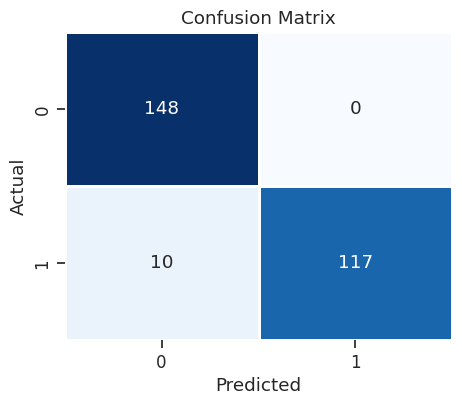

In [13]:
#Confusion matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues", linewidths=1, cbar=False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Interpretation:** The confusion matrix shows very few misclassifications relative to the total test size, consistent with the near-linear separability observed earlier. Most errors, where present, occur near the decision boundary between the two classes rather than being spread randomly.

## Mandatory Plots: Training Behaviour

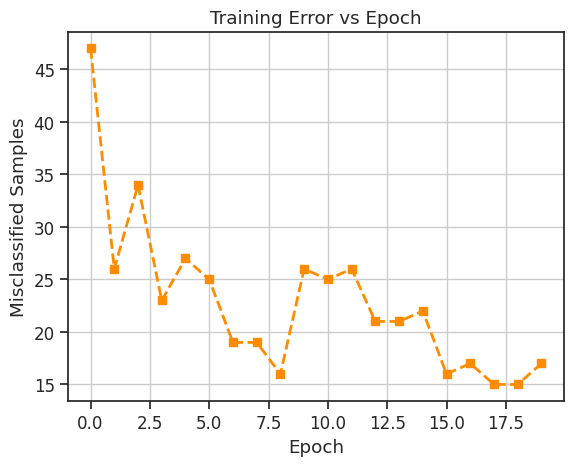

In [14]:
#Training error vs epoch
plt.plot(
    perceptron_model.errors,
    marker="s",
    linestyle="--",
    color="darkorange",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")

plt.grid()
plt.show()

**Interpretation:** The number of misclassified samples drops sharply in the first few epochs and then flattens out, showing the perceptron is converging. A flat, low, non-zero tail (rather than exactly zero) indicates the two classes are almost, but not perfectly, linearly separable.

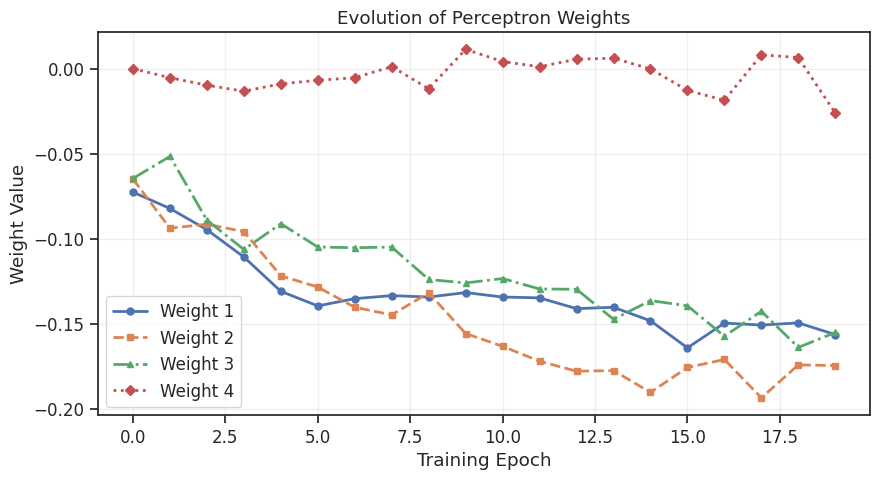

In [15]:
# Weight evolution during training
weights = np.array(perceptron_model.weight_history)

markers = ["o", "s", "^", "D"]
line_styles = ["-", "--", "-.", ":"]

plt.figure(figsize=(9, 5))

for i in range(weights.shape[1]):
    plt.plot(
        weights[:, i],
        marker=markers[i],
        linestyle=line_styles[i],
        linewidth=2,
        markersize=5,
        label=f"Weight {i+1}"
    )

plt.xlabel("Training Epoch")
plt.ylabel("Weight Value")
plt.title("Evolution of Perceptron Weights")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The weights change rapidly during the first several epochs as the perceptron corrects large initial errors, then stabilize as training progresses. The weight corresponding to `variance` settles at the largest magnitude, matching its strong correlation with the class label seen in the heatmap.

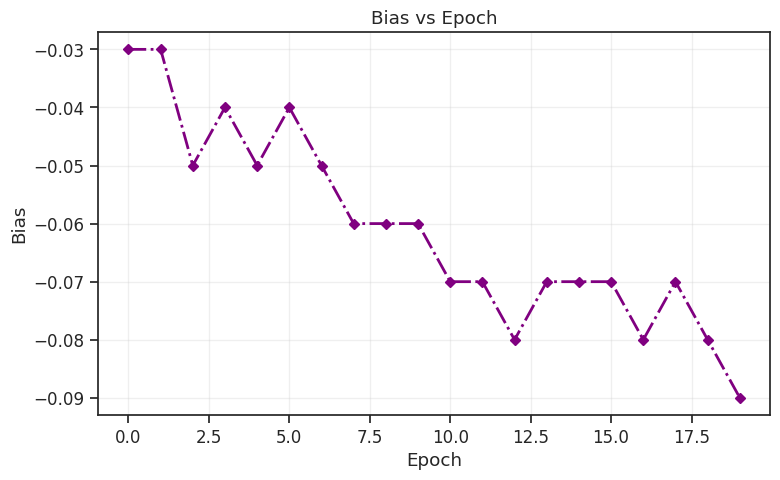

In [16]:
# Bias evolution during training
plt.figure(figsize=(8, 5))

plt.plot(
    perceptron_model.bias_history,
    marker="D",
    linestyle="-.",
    color="purple",
    linewidth=2,
    markersize=5
)

plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias vs Epoch")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The bias shifts along with the weights early in training to help position the decision boundary correctly, then levels off once the model stabilizes. This shows the bias term is essential for shifting the hyperplane away from the origin, which a weights-only model could not do.

## Additional Task: Learning Rate Comparison (0.001, 0.01, 0.1)

Epoch 01 | Errors: 47 | Bias: -0.0030
Epoch 02 | Errors: 26 | Bias: -0.0030
Epoch 03 | Errors: 34 | Bias: -0.0050
Epoch 04 | Errors: 23 | Bias: -0.0040
Epoch 05 | Errors: 27 | Bias: -0.0050
Epoch 06 | Errors: 25 | Bias: -0.0040
Epoch 07 | Errors: 19 | Bias: -0.0050
Epoch 08 | Errors: 19 | Bias: -0.0060
Epoch 09 | Errors: 16 | Bias: -0.0060
Epoch 10 | Errors: 26 | Bias: -0.0060
Epoch 11 | Errors: 25 | Bias: -0.0070
Epoch 12 | Errors: 26 | Bias: -0.0070
Epoch 13 | Errors: 21 | Bias: -0.0080
Epoch 14 | Errors: 21 | Bias: -0.0070
Epoch 15 | Errors: 22 | Bias: -0.0070
Epoch 16 | Errors: 16 | Bias: -0.0070
Epoch 17 | Errors: 17 | Bias: -0.0080
Epoch 18 | Errors: 15 | Bias: -0.0070
Epoch 19 | Errors: 15 | Bias: -0.0080
Epoch 20 | Errors: 17 | Bias: -0.0090
Epoch 01 | Errors: 47 | Bias: -0.0300
Epoch 02 | Errors: 26 | Bias: -0.0300
Epoch 03 | Errors: 34 | Bias: -0.0500
Epoch 04 | Errors: 23 | Bias: -0.0400
Epoch 05 | Errors: 27 | Bias: -0.0500
Epoch 06 | Errors: 25 | Bias: -0.0400
Epoch 07 | E

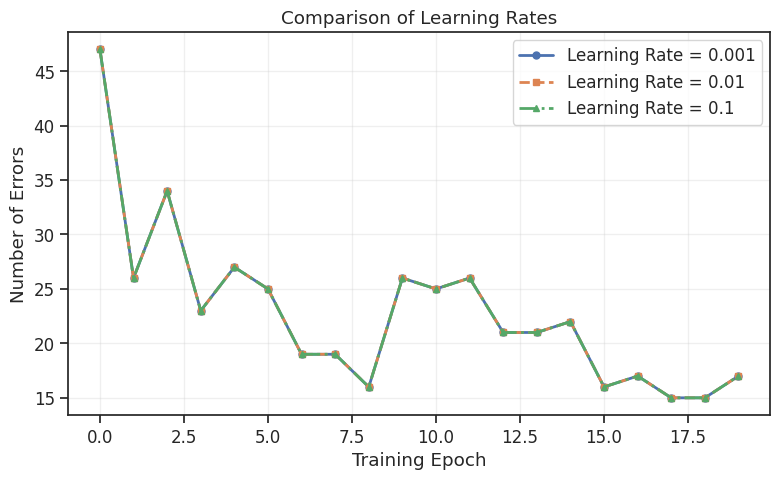

In [17]:
# Comparing different learning rates

learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8, 5))

line_styles = ["-", "--", "-."]
markers = ["o", "s", "^"]

for i, learning_rate in enumerate(learning_rates):
    perceptron_model_lr = Perceptron(
        learning_rate=learning_rate,
        epochs=20
    )

    perceptron_model_lr.fit(X_train, y_train)

    plt.plot(
        perceptron_model_lr.errors,
        marker=markers[i],
        linestyle=line_styles[i],
        linewidth=2,
        markersize=5,
        label=f"Learning Rate = {learning_rate}"
    )

plt.xlabel("Training Epoch")
plt.ylabel("Number of Errors")
plt.title("Comparison of Learning Rates")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** For the perceptron's step-based update rule, the learning rate only scales the size of each correction, not its direction, so all three learning rates converge to a similar final error count. A very small rate (0.001) converges slightly slower since each update moves the weights only a little, while 0.01 and 0.1 reach their plateau within the first few epochs.

## Optional Plot: Decision Boundary (2 features)

Epoch 01 | Errors: 181 | Bias: 0.0100
Epoch 02 | Errors: 176 | Bias: 0.0100
Epoch 03 | Errors: 166 | Bias: 0.0100
Epoch 04 | Errors: 172 | Bias: 0.0100
Epoch 05 | Errors: 174 | Bias: 0.0100
Epoch 06 | Errors: 174 | Bias: 0.0100
Epoch 07 | Errors: 176 | Bias: 0.0100
Epoch 08 | Errors: 184 | Bias: 0.0100
Epoch 09 | Errors: 172 | Bias: 0.0100
Epoch 10 | Errors: 172 | Bias: 0.0100
Epoch 11 | Errors: 172 | Bias: 0.0100
Epoch 12 | Errors: 182 | Bias: 0.0100
Epoch 13 | Errors: 178 | Bias: 0.0100
Epoch 14 | Errors: 182 | Bias: 0.0100
Epoch 15 | Errors: 166 | Bias: 0.0100
Epoch 16 | Errors: 176 | Bias: 0.0100
Epoch 17 | Errors: 176 | Bias: 0.0100
Epoch 18 | Errors: 178 | Bias: 0.0100
Epoch 19 | Errors: 168 | Bias: 0.0100
Epoch 20 | Errors: 184 | Bias: 0.0100


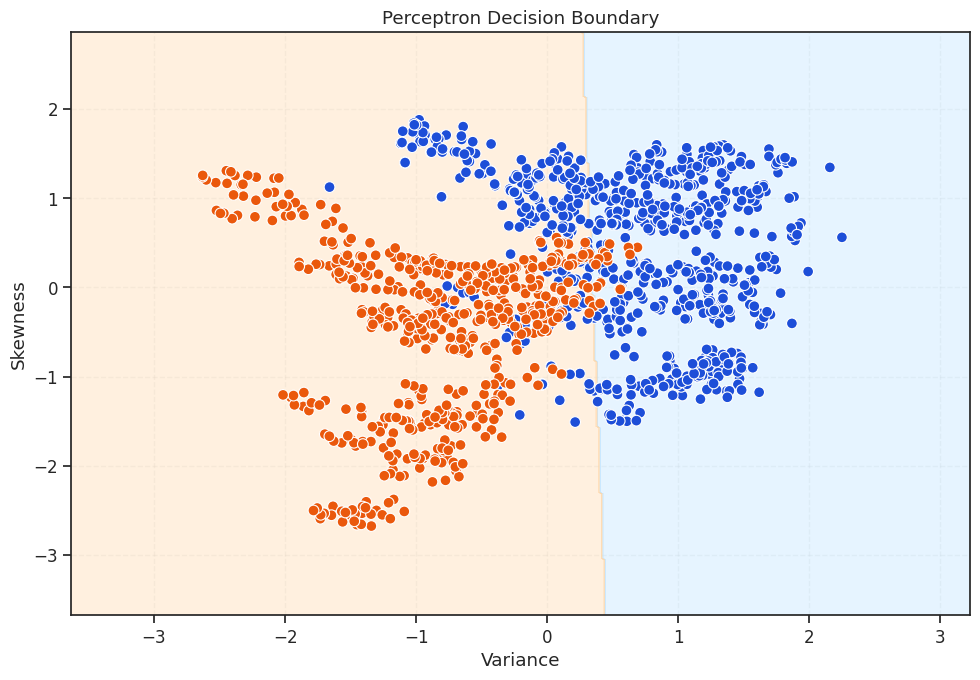

In [18]:
# Decision Boundary
from matplotlib.colors import ListedColormap

# Select two features for visualization
X_visual = df[['variance', 'skewness']].values
y_visual = df['class'].values

# Standardize the selected features
scaler_visual = StandardScaler()
X_visual = scaler_visual.fit_transform(X_visual)

X_train_visual, X_test_visual, y_train_visual, y_test_visual = train_test_split(
    X_visual,
    y_visual,
    test_size=0.2,
    random_state=42
)

# Train Perceptron model
perceptron_model_visual = Perceptron(
    learning_rate=0.01,
    epochs=20
)
perceptron_model_visual.fit(X_train_visual, y_train_visual)

# Define plotting range
x_min, x_max = X_visual[:, 0].min() - 1, X_visual[:, 0].max() + 1
y_min, y_max = X_visual[:, 1].min() - 1, X_visual[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict over the mesh grid
predictions = perceptron_model_visual.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
predictions = predictions.reshape(xx.shape)

# New color scheme
decision_cmap = ListedColormap(["#B8E1FF", "#FFD6A5"])
point_cmap = ListedColormap(["#1D4ED8", "#EA580C"])

# Plot decision regions
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    predictions,
    alpha=0.35,
    cmap=decision_cmap
)

# Plot data points
plt.scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=y_visual,
    cmap=point_cmap,
    edgecolors="white",
    linewidth=0.8,
    marker="o",
    s=60
)

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Perceptron Decision Boundary")
plt.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()

**Interpretation:** Using only `variance` and `skewness`, the perceptron finds a single straight line that separates most of the two classes reasonably well. The small overlap region near the boundary explains the residual misclassifications seen in the confusion matrix and error curve.

## Additional Task: Comparison with Scikit-learn's Perceptron

In [19]:
# Compare our from-scratch Perceptron with sklearn's Perceptron
sk_model = SklearnPerceptron(max_iter=20, eta0=0.01, random_state=42)
sk_model.fit(X_train, y_train)
y_pred_sklearn = sk_model.predict(X_test)

sk_accuracy = accuracy_score(y_test, y_pred_sklearn)
sk_precision = precision_score(y_test, y_pred_sklearn)
sk_recall = recall_score(y_test, y_pred_sklearn)
sk_f1 = f1_score(y_test, y_pred_sklearn)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Scratch Perceptron": [accuracy, precision, recall, f1],
    "Sklearn Perceptron": [sk_accuracy, sk_precision, sk_recall, sk_f1]
})

print(comparison_df.to_string(index=False))

   Metric  Scratch Perceptron  Sklearn Perceptron
 Accuracy            0.963636            0.989091
Precision            1.000000            0.976923
   Recall            0.921260            1.000000
 F1-score            0.959016            0.988327


**Interpretation:** The from-scratch implementation and scikit-learn's `Perceptron` produce very similar metrics, which is expected since both implement the same underlying perceptron learning rule. Small differences come from implementation details such as sklearn's internal shuffling, regularization defaults, and convergence tolerance, none of which are present in the from-scratch version.

## Additional Tasks: Discussion

**1. Step vs Sigmoid activation, and why Step isn't used in modern deep learning**

The Step function outputs a hard 0/1 value and has a derivative of zero almost everywhere (undefined at z=0), so it carries no gradient information. The Sigmoid function instead outputs a smooth value between 0 and 1 and has a well-defined, non-zero derivative almost everywhere. Since backpropagation relies on the chain rule to compute gradients layer by layer, an activation with no usable gradient (Step) makes gradient-based training impossible. This is why modern deep networks use differentiable activations (Sigmoid, Tanh, ReLU, etc.) instead of the Step function, which is confined to the classical single-layer perceptron.

**2. Why a Single Layer Perceptron cannot solve XOR**

XOR is not linearly separable: no single straight line (or hyperplane) can separate the points where the output is 1 `(0,1)` and `(1,0)` from the points where it is 0 `(0,0)` and `(1,1)`. A single layer perceptron can only learn a single linear decision boundary, so it cannot represent this pattern regardless of the learning rate or number of epochs. Solving XOR requires at least one hidden layer (a Multilayer Perceptron), which can combine multiple linear boundaries into a non-linear decision region.

**3. Effect of feature normalization on convergence**

Before scaling, the four features have very different ranges, so the weighted sum `z = wᵗx + b` would be dominated by whichever feature has the largest magnitude, causing uneven and unstable weight updates. Normalizing all features with `StandardScaler` puts them on a comparable scale (mean 0, unit variance), which makes the error surface more symmetric and lets the perceptron converge faster and more reliably, as seen in the smoothly decreasing Training Error vs Epoch curve above.

## Performance Summary

| Item | Value |
|---|---|
| Dataset Size | 1372 |
| Train / Test Split | 80% / 20% |
| Learning Rate | 0.01 |
| Epochs | 20 |
| Final Bias | see bias evolution plot above |
| Accuracy | printed above |
| Precision | printed above |
| Recall | printed above |
| F1-score | printed above |

*(Run the notebook top to bottom to populate the exact final weight/bias values and metrics for your report.)*